In [1]:
import os
import re
from pathlib import Path

import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO
from transformers import AutoProcessor, LlavaForConditionalGeneration

/home/myid/bp67339/Unblockr/backend/unblockr_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("CUDA:", torch.cuda.is_available())

IMAGE_PATH = Path("../data/test_images/test3.png")
assert IMAGE_PATH.exists(), "test2.png not found"

OUTPUT_DIR = Path("../data/outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

VEHICLE_CLASSES = {2, 3, 5, 7}

CLASS_NAME_MAP = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck",
}

CUDA: True


In [3]:
yolo_model = YOLO("yolov8n.pt")
print("YOLO loaded")

YOLO loaded


In [4]:
MODEL_ID = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_ID)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("LLaVA loaded")

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 10960.72it/s]
/home/myid/bp67339/Unblockr/backend/unblockr_env/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Loading weights: 100%|██████████| 686/686 [00:03<00:00, 196.34it/s]


LLaVA loaded


In [5]:
def load_image_rgb(path):
    img = cv2.imread(str(path))
    assert img is not None, "Image failed to load"
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [6]:
def detect_vehicles(image_path):
    results = yolo_model(str(image_path), verbose=False)
    vehicles = []

    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            if cls in VEHICLE_CLASSES and conf > 0.5:  # 🔥 FILTER
                vehicles.append({
                    "id": f"v{len(vehicles)+1}",
                    "class_name": CLASS_NAME_MAP.get(cls, "vehicle"),
                    "confidence": round(conf, 2),
                    "bbox": [x1, y1, x2, y2],
                })

    return vehicles

In [7]:
def draw_boxes(image, vehicles):
    img = image.copy()

    for v in vehicles:
        x1, y1, x2, y2 = map(int, v["bbox"])

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            v["id"],
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    return img

In [8]:
def get_center(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1 + x2) / 2, (y1 + y2) / 2)

def build_scene(vehicles):
    if not vehicles:
        return "No vehicles detected."

    lines = []
    for v in vehicles:
        cx, cy = get_center(v["bbox"])
        lines.append(f"{v['id']} ({v['class_name']}) at ({int(cx)}, {int(cy)})")

    return "Vehicles:\n" + "\n".join(lines)

Vehicles: 3
{'id': 'v1', 'class_name': 'car', 'confidence': 0.91, 'bbox': [77.53677368164062, 288.014404296875, 580.6276245117188, 544.8214721679688]}
{'id': 'v2', 'class_name': 'bus', 'confidence': 0.83, 'bbox': [565.2310180664062, 183.6808624267578, 990.7322998046875, 554.67626953125]}
{'id': 'v3', 'class_name': 'car', 'confidence': 0.79, 'bbox': [0.14312267303466797, 301.1116638183594, 86.6352767944336, 560.2141723632812]}

Scene:
 Vehicles:
v1 (car) at (329, 416)
v2 (bus) at (777, 369)
v3 (car) at (43, 430)


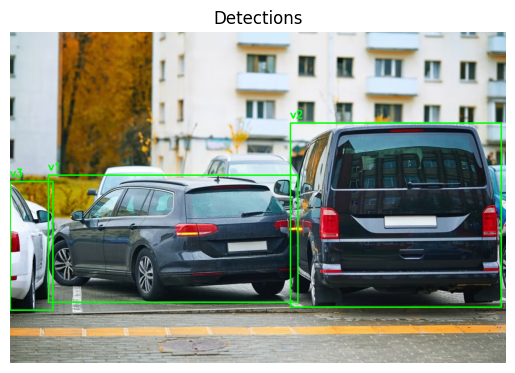

In [9]:
image_rgb = load_image_rgb(IMAGE_PATH)

vehicles = detect_vehicles(IMAGE_PATH)

print("Vehicles:", len(vehicles))
for v in vehicles:
    print(v)

annotated = draw_boxes(image_rgb, vehicles)

plt.imshow(annotated)
plt.title("Detections")
plt.axis("off")

scene_text = build_scene(vehicles)
print("\nScene:\n", scene_text)

In [10]:
PROMPT = """
You are analyzing a parking scene.

Vehicles are labeled as v1, v2, v3, etc. You MUST ONLY use these IDs.

DO NOT use placeholders like VX or VY.

Answer:

1. Is any vehicle blocked and unable to move?
2. If yes, which vehicle (choose from v1, v2, v3...)?
3. Which vehicles block it (choose from v1, v2, v3...)?

Important:
- Only use the exact IDs provided
- Do not invent new IDs

Respond EXACTLY in this format:

blocked: yes/no
blocked_car: v1
blocking_cars: [v2, v3]
"""

In [11]:
def ask_llava(image, prompt, scene_text):
    pil_image = Image.fromarray(image)

    full_prompt = f"""
Scene:
{scene_text}

{prompt}
"""

    inputs = processor(
        text=f"USER: <image>\n{full_prompt}\nASSISTANT:",
        images=pil_image,
        return_tensors="pt"
    )

    inputs = {k: v.to(llava_model.device) for k, v in inputs.items()}

    output = llava_model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

    return processor.decode(output[0], skip_special_tokens=True)

In [12]:
response = ask_llava(annotated, PROMPT, scene_text)

print(response)

USER:  

Scene:
Vehicles:
v1 (car) at (329, 416)
v2 (bus) at (777, 369)
v3 (car) at (43, 430)


You are analyzing a parking scene.

Vehicles are labeled as v1, v2, v3, etc. You MUST ONLY use these IDs.

DO NOT use placeholders like VX or VY.

Answer:

1. Is any vehicle blocked and unable to move?
2. If yes, which vehicle (choose from v1, v2, v3...)?
3. Which vehicles block it (choose from v1, v2, v3...)?

Important:
- Only use the exact IDs provided
- Do not invent new IDs

Respond EXACTLY in this format:

blocked: yes/no
blocked_car: v1
blocking_cars: [v2, v3]


ASSISTANT: 1. No
2. No
3. v1, v2, v3


In [13]:
def parse_answer(text):
    text = text.lower()

    is_blocked = "yes" in text

    # Extract all IDs
    ids = re.findall(r"v\d+", text)

    if not ids:
        return {
            "is_blocked": False,
            "blocked_vehicle": None,
            "blocking_vehicles": []
        }

    # First ID = blocked
    blocked = ids[0]

    # Rest = blocking
    blocking = ids[1:]

    # 🔥 CLEANUP
    blocking = list(set(blocking))  # remove duplicates
    if blocked in blocking:
        blocking.remove(blocked)

    return {
        "is_blocked": is_blocked,
        "blocked_vehicle": blocked,
        "blocking_vehicles": blocking
    }

In [14]:
result = parse_answer(response)

print("\nFINAL RESULT:")
print(result)


FINAL RESULT:
{'is_blocked': True, 'blocked_vehicle': 'v1', 'blocking_vehicles': ['v3', 'v2']}
